# **Project Title:** Seasonal Agriculture Performance Analysis

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DATA EXPLORATION AND DATA CLEANING

In [3]:
df = pd.read_csv("agriculture_data.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("The Shape of the dataset:",df.shape)

The Shape of the dataset: (4000, 28)


## **Handling Null Values**

In [5]:
print("Nulls present in the dataset column wise")
df.isnull().sum()

Nulls present in the dataset column wise


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [58]:
# 1. Fill missing Yield using the ratio of Production_Tonnes to Farm_Area_Hectares
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Production_Tonnes"] / df["Farm_Area_Hectares"]
)
# 2. Fill missing Rainfall using the median for that State and Season
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
    df.groupby(["State", "Season"])["Rainfall_mm"].transform("median")
)

# Verify no nulls remain in these columns
print(df[["Yield_Tonnes_Ha", "Rainfall_mm"]].isnull().sum())
df.isnull().sum()

Yield_Tonnes_Ha      0
Rainfall_mm          0
Soil_Moisture_pct    0
dtype: int64


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


**Handling Duplicate Values**

In [8]:
duplicate_count = df.duplicated().sum()
print('Duplicate Rows',duplicate_count)

Duplicate Rows 0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

**Categorical columns**

In [10]:
df['State'].unique()

array(['Andhra Pradesh', 'Maharashtra', 'Telangana', 'Karnataka',
       'Gujarat', 'Tamil Nadu', 'Punjab', 'Madhya Pradesh'], dtype=object)

In [11]:
df['District'].unique()

array(['Rajkot', 'Nalgonda', 'Warangal', 'Indore', 'Ludhiana', 'Raichur',
       'Guntur', 'Krishna', 'Nashik', 'Erode'], dtype=object)

In [12]:
df['Season'].unique()

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

In [13]:
df['Crop'].unique()

array(['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli',
       'Groundnut', 'Sugarcane'], dtype=object)

In [14]:
df['Irrigation_Method'].unique()

array(['Drip', 'Flood', 'Rainfed', 'Sprinkler'], dtype=object)

**Statistical Summary of Data**

In [15]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.741475,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.262843,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.396031,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.343283,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.298592,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.425000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,581.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,836.125000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


### Box plots for all numerical columns

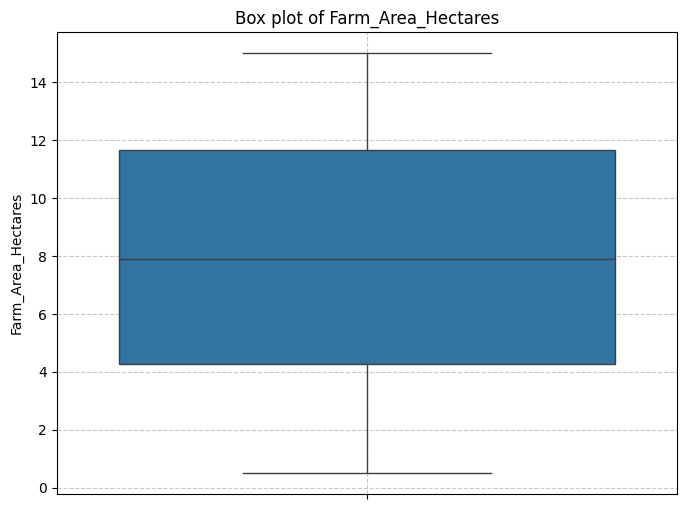

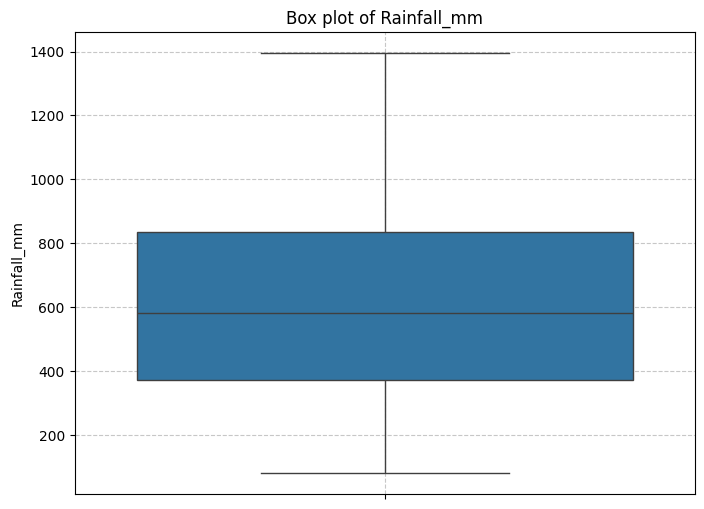

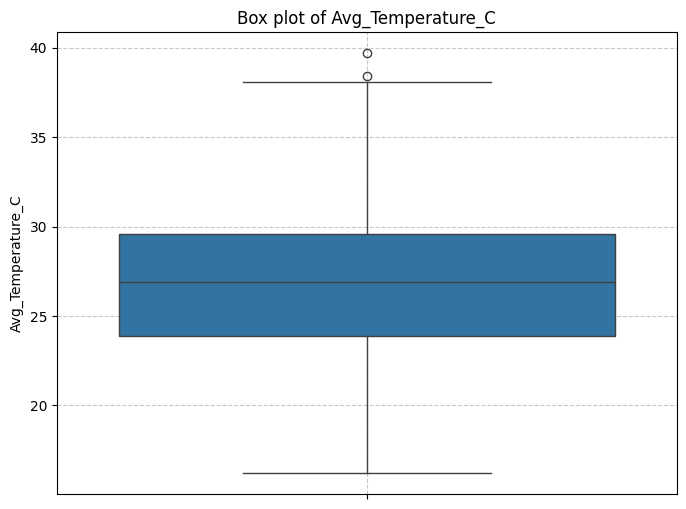

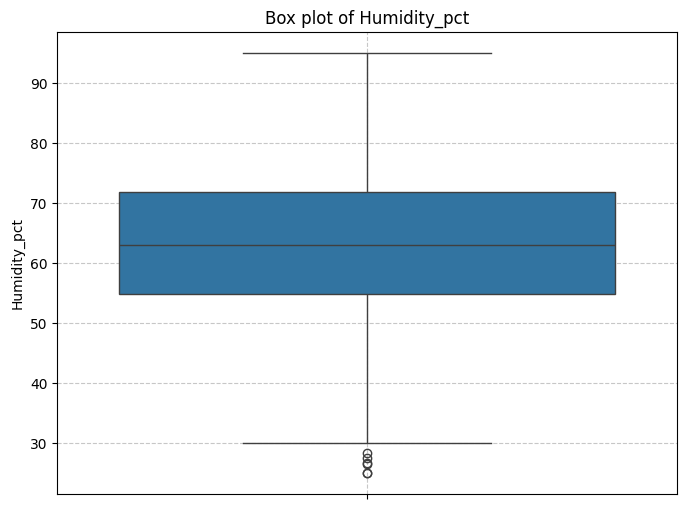

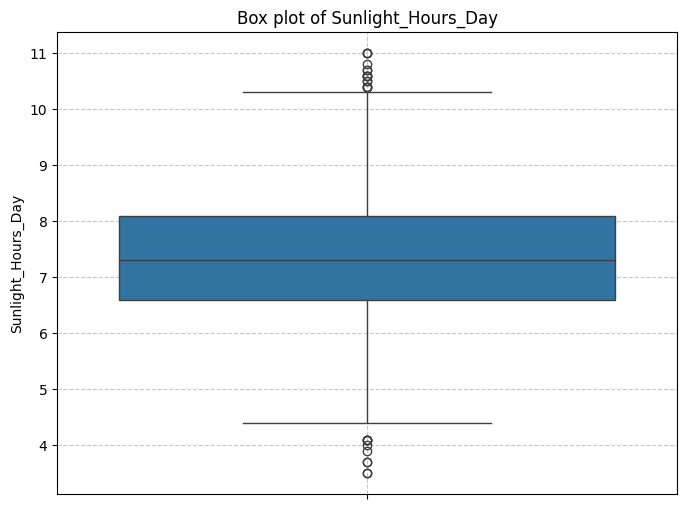

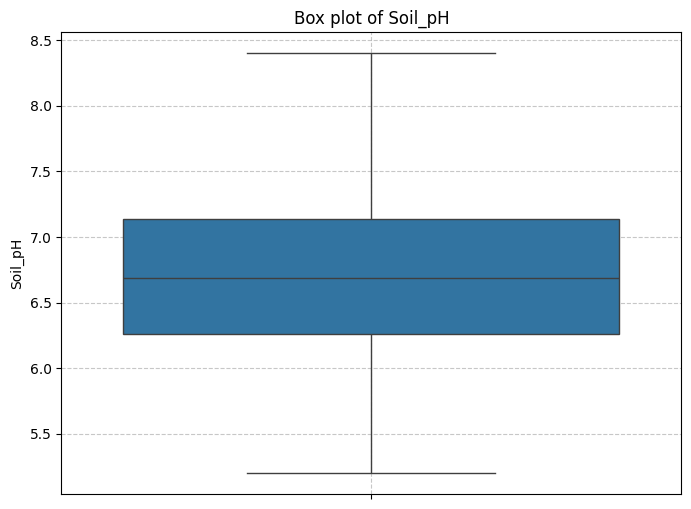

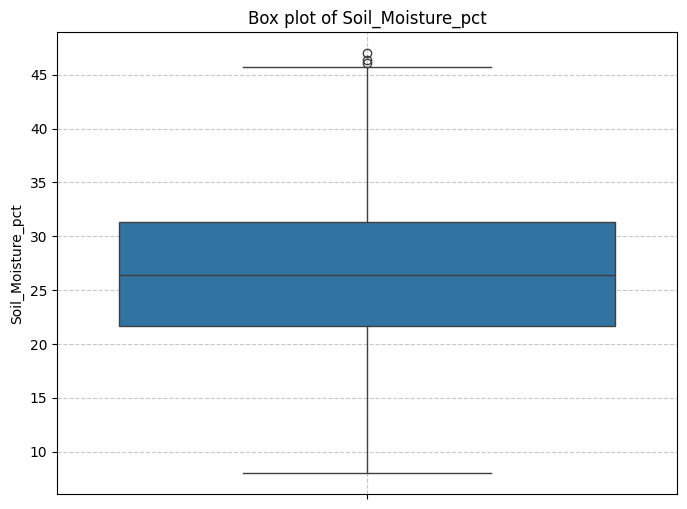

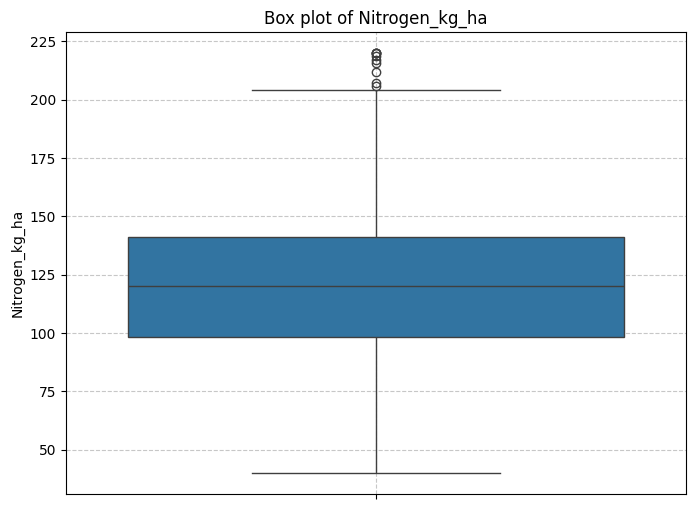

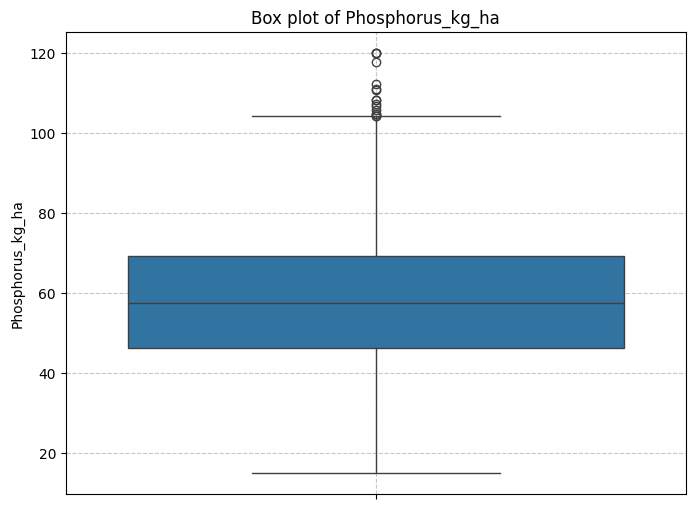

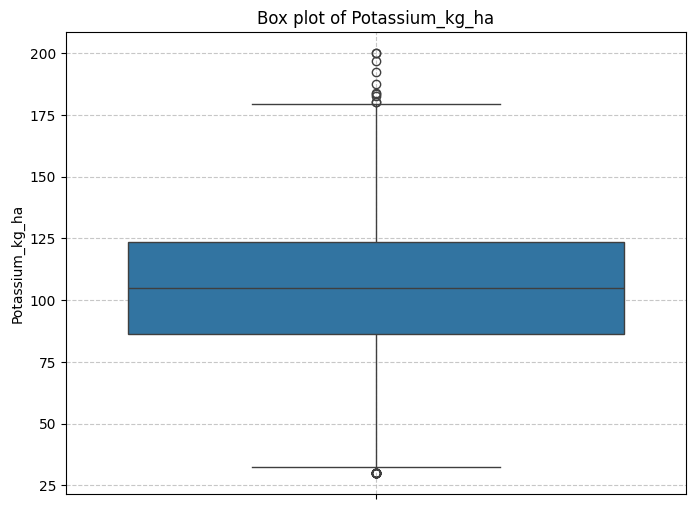

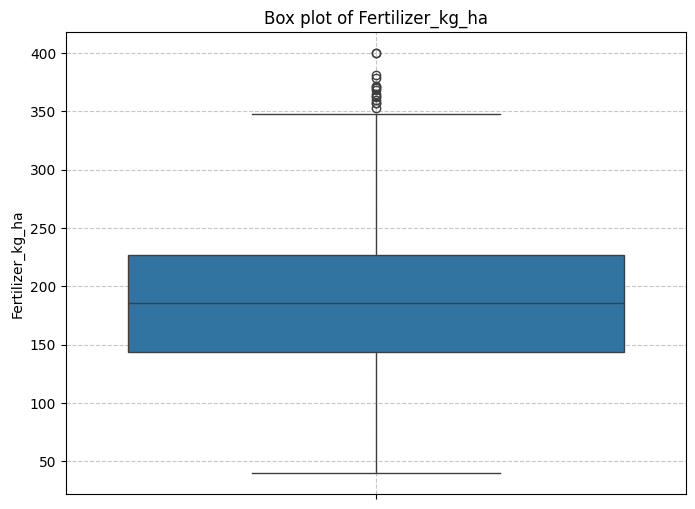

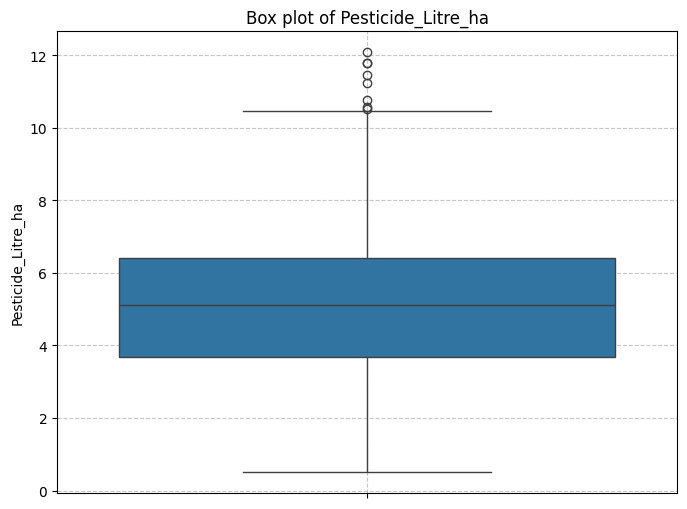

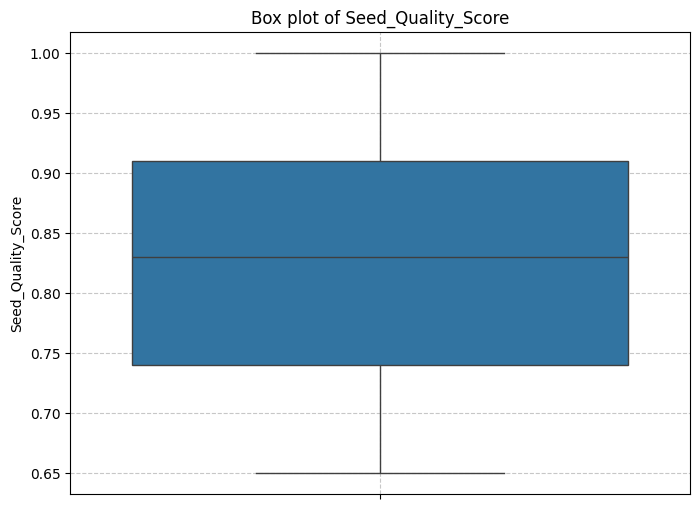

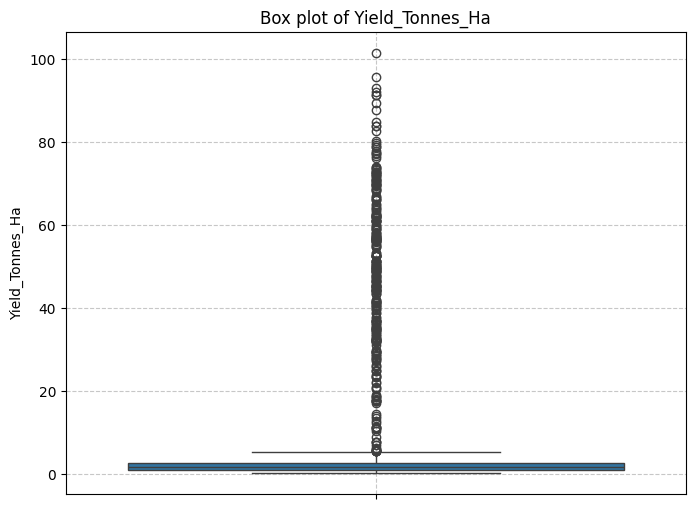

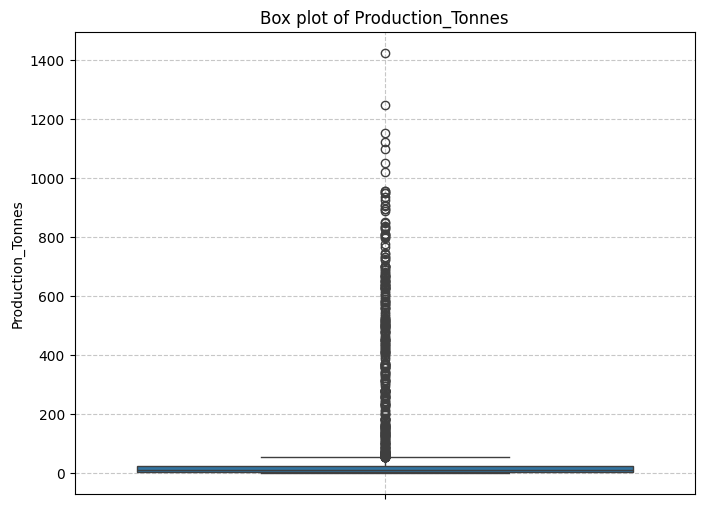

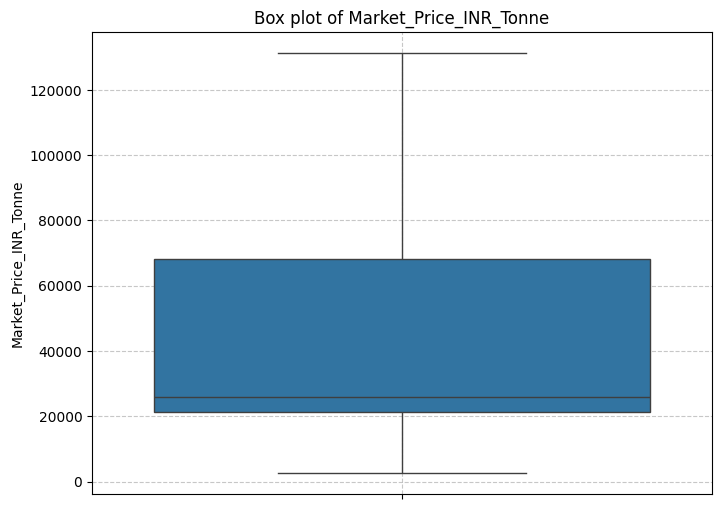

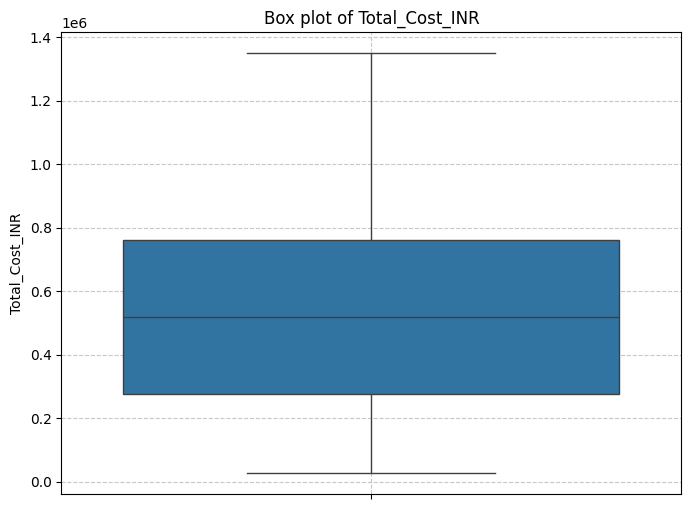

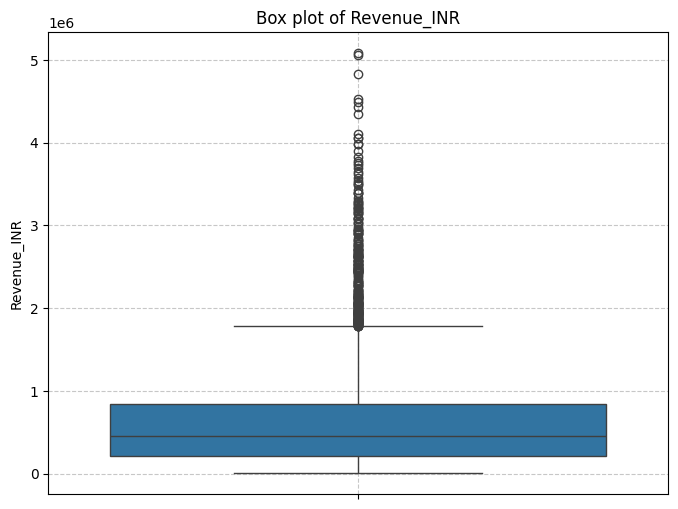

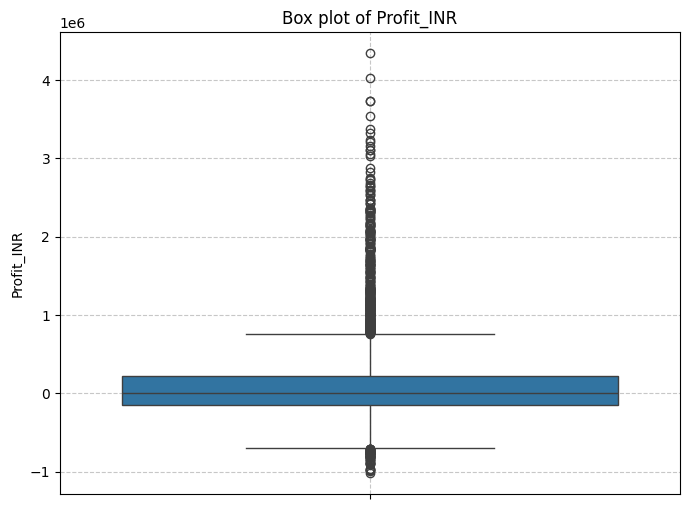

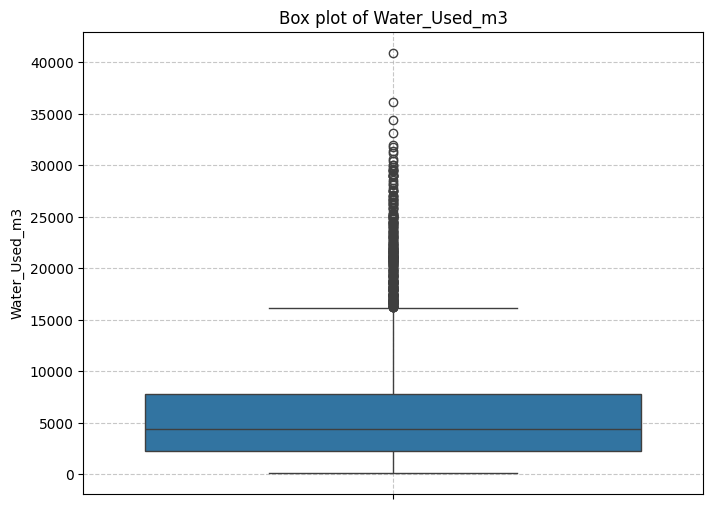

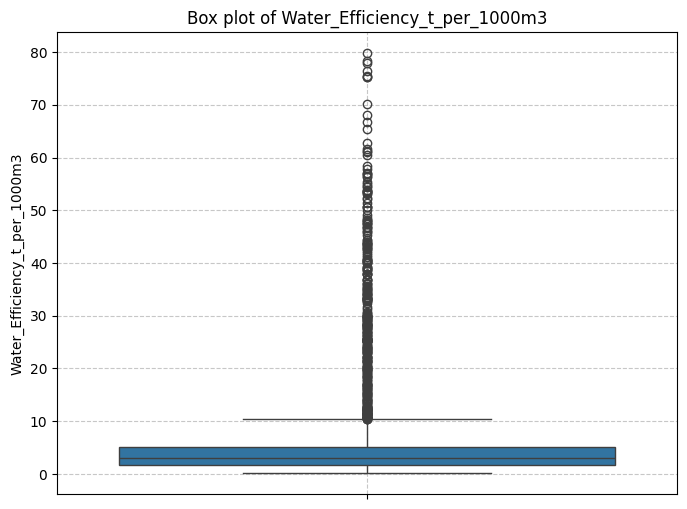

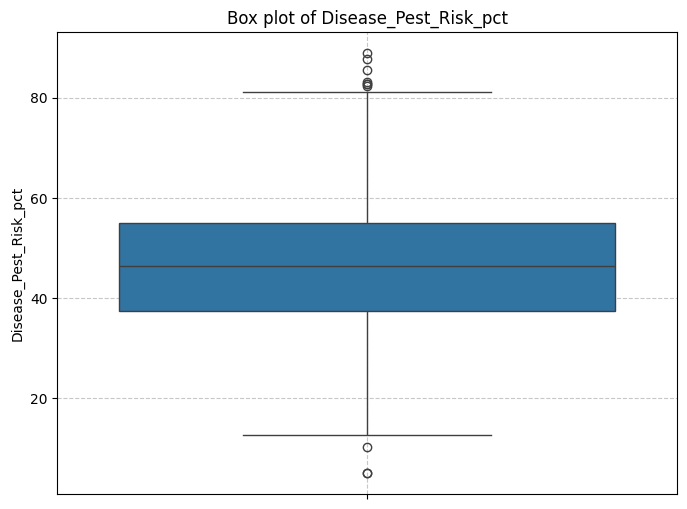

In [16]:
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

In [17]:
if "Profit_Loss_Pct" in df.columns:
  df.drop(columns=["Profit_Loss_Pct"], inplace=True)
df.insert(
    loc=25,
    column="Profit_Loss_Pct",
    value=((df["Profit_INR"] / df["Total_Cost_INR"]) * 100).round(2)
)

In [18]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Loss_Pct,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,2.46,1.30,23700,42662,30810,-11852,-27.78,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.30,1.96,20613,492351,40401,-451950,-91.79,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.52,2.53,75283,315210,190466,-124744,-39.57,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,1.84,8.28,24244,296444,200740,-95704,-32.28,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,2.21,9.30,20818,337959,193607,-144352,-42.71,3287,2.829,32.3


**Crops Distribution per each State**

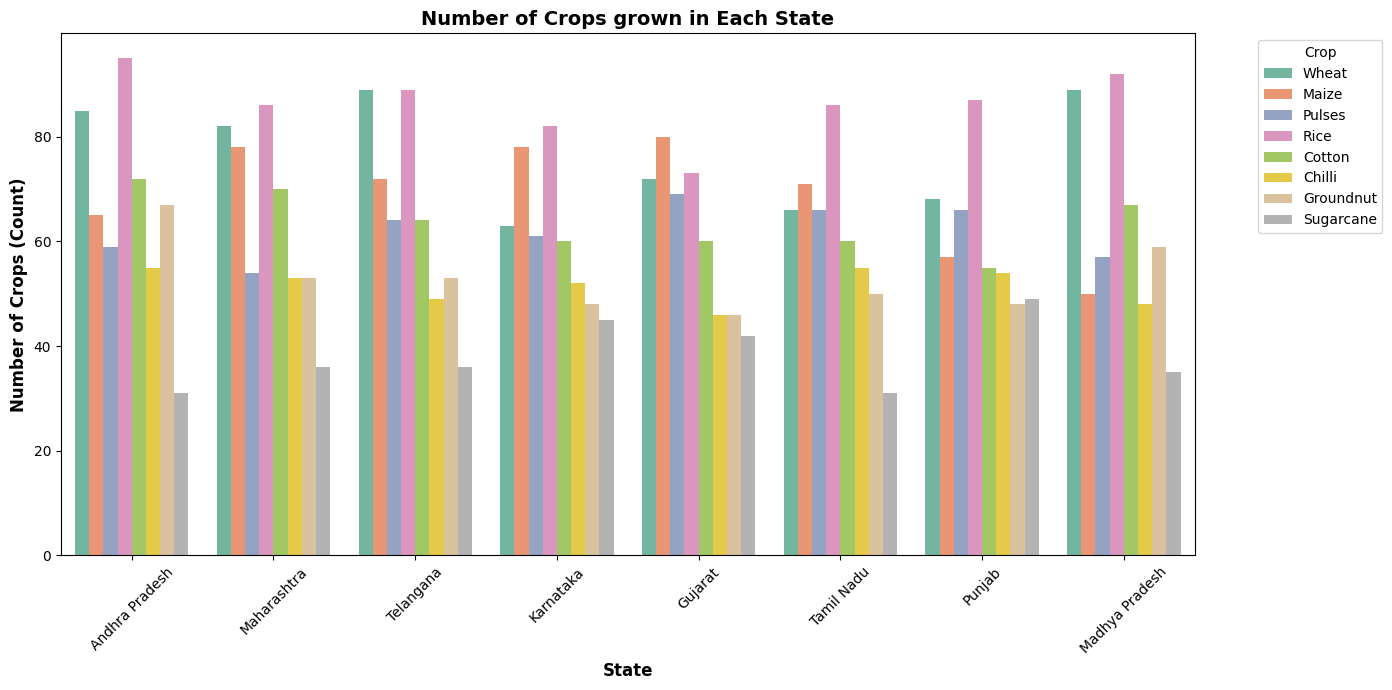

In [75]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='State', hue='Crop', palette='Set2')
plt.title('Number of Crops grown in Each State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12, fontweight='bold')
plt.ylabel('Number of Crops (Count)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

**Univariate Analysis - Crop Distribution**

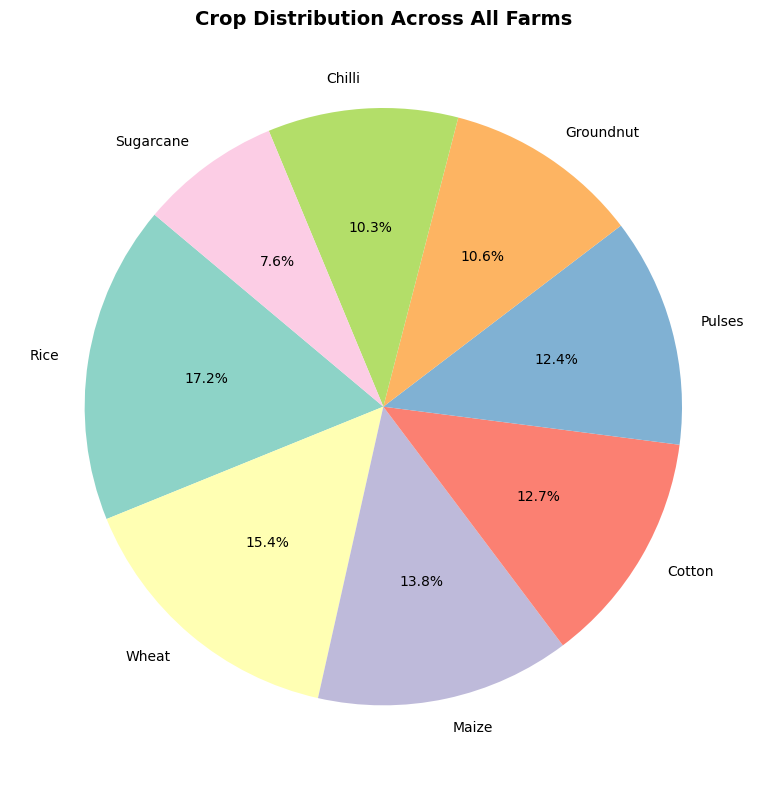

In [20]:
crop_counts = df['Crop'].value_counts()

# simple pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    crop_counts,
    labels=crop_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors[:len(crop_counts)]
)

plt.title('Crop Distribution Across All Farms', fontsize=14, fontweight='bold')
plt.tight_layout()

**Univariate Analysis-Irrigation Method Distribution**
To analyse which is the most and least used irrigation Method

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


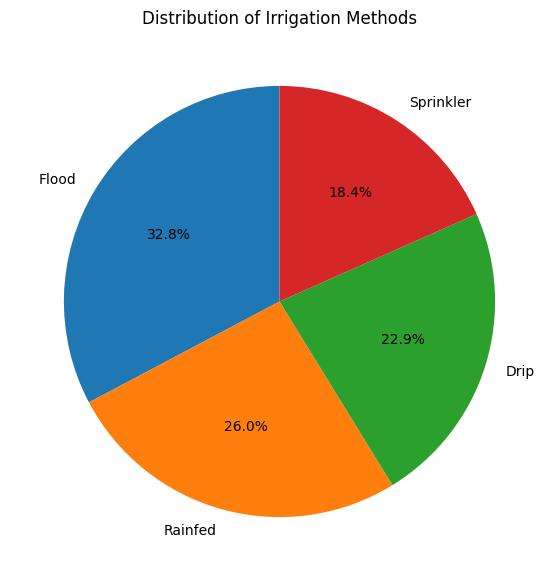

In [70]:

irrigation_method_info = df["Irrigation_Method"].value_counts()

print(irrigation_method_info)

plt.figure(figsize=(7, 7))

plt.pie(
    irrigation_method_info,
    labels=irrigation_method_info.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Irrigation Methods")

plt.show()

**Bivariate Analysis**

Crops vs Profit Loss Percentage

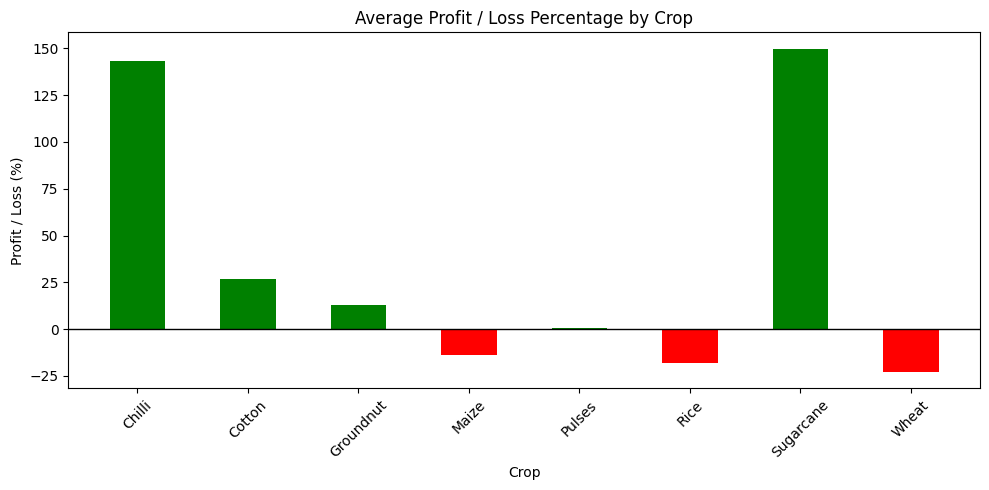

In [22]:


# 1. Group data to get average profit percentage per crop
crop_profit = df.groupby("Crop")["Profit_Loss_Pct"].mean().reset_index()

# 2. Set colors: Green for positive %, Red for negative %
colors = ["green" if x >= 0 else "red" for x in crop_profit["Profit_Loss_Pct"]]

# 3. Create bar chart
plt.figure(figsize=(10, 5))
plt.bar(
    crop_profit["Crop"],
    crop_profit["Profit_Loss_Pct"],
    color=colors,
    width=0.5,
)

# 4. Add horizontal baseline at 0
plt.axhline(0, color="black", linewidth=1)

plt.title("Average Profit / Loss Percentage by Crop")
plt.xlabel("Crop")
plt.ylabel("Profit / Loss (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Let's check the productivity of different crops w.r.t different attributes

### Average Yield (Tonnes/Ha) w.r.t Crop and Season

In [23]:
crop_season_yield = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().reset_index()
display(crop_season_yield.pivot(index='Crop', columns='Season', values='Yield_Tonnes_Ha'))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.726594,1.459022,1.183749
Cotton,1.373022,1.193693,0.944560
Groundnut,1.481712,1.225648,1.037778
Maize,2.966410,2.616394,2.276190
Pulses,1.036063,0.872298,0.646429
Rice,2.706906,2.326805,1.900490
Sugarcane,53.459120,43.954495,38.423922
Wheat,2.251536,2.059075,1.748588


Average Yield and Environmental conditions with respect to Crop and Season

In [36]:
seasonal_environment_stats = df.groupby(["Crop",'Season']).agg(
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Humidity_pct=('Humidity_pct', 'mean'),
    Avg_Sunlight_Hours_Day=('Sunlight_Hours_Day', 'mean'),
    Avg_Yield_Tonnes_Ha=('Yield_Tonnes_Ha', 'mean')
).reset_index()

print("Average Environmental Conditions by Season:")
display(seasonal_environment_stats)

Average Environmental Conditions by Season:


,Crop,Season,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Humidity_pct,Avg_Sunlight_Hours_Day,Avg_Yield_Tonnes_Ha
0,Chilli,Kharif,844.557838,28.470270,71.017297,6.887027,1.726594
1,Chilli,Rabi,429.831288,23.503067,57.495092,7.666258,1.459022
2,Chilli,Zaid,311.992188,31.704687,51.793750,8.220313,1.183749
3,Cotton,Kharif,850.765581,28.576279,71.254419,6.883256,1.373022
4,Cotton,Rabi,464.308209,23.352239,57.775622,7.556716,1.193693
5,Cotton,Zaid,292.638043,30.873913,53.032609,8.122826,0.944560
6,Groundnut,Kharif,849.654404,28.408808,72.490155,6.750259,1.481712
7,Groundnut,Rabi,407.505650,23.383051,59.050847,7.572881,1.225648
8,Groundnut,Zaid,282.574074,30.681481,52.172222,8.024074,1.037778
9,Maize,Kharif,865.835684,28.674359,71.944444,6.841026,2.966410


Average Yield and Environmental Conditions w.r.t State and Season

In [25]:
# Group by State and Season
state_seasonal_stats = (
    df.groupby(["State", "Season"])
    .agg(
        Avg_Rainfall_mm=("Rainfall_mm", "mean"),
        Avg_Temperature_C=("Avg_Temperature_C", "mean"),
        Avg_Humidity_pct=("Humidity_pct", "mean"),
        Avg_Sunlight_Hours_Day=("Sunlight_Hours_Day", "mean"),
    )
    .round(2)
    .reset_index()
)

print("Average Environmental Conditions by State and Season:")
display(state_seasonal_stats)

Average Environmental Conditions by State and Season:


,State,Season,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Humidity_pct,Avg_Sunlight_Hours_Day
0,Andhra Pradesh,Kharif,858.20,28.31,72.12,6.81
1,Andhra Pradesh,Rabi,440.26,23.65,57.45,7.57
2,Andhra Pradesh,Zaid,301.84,30.96,52.97,8.06
3,Gujarat,Kharif,844.78,28.53,71.34,6.63
4,Gujarat,Rabi,428.76,23.44,58.29,7.63
5,Gujarat,Zaid,285.71,30.41,53.49,8.11
6,Karnataka,Kharif,841.90,28.33,71.62,6.83
7,Karnataka,Rabi,433.59,23.35,57.94,7.66
8,Karnataka,Zaid,278.87,31.27,51.26,8.18
9,Madhya Pradesh,Kharif,864.46,28.47,72.04,6.83


### Average Yield (Tonnes/Ha) by Seed Quality Score

/tmp/ipykernel_514/1834503949.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seed_quality_yield = df.groupby('Seed_Quality_Category')['Yield_Tonnes_Ha'].mean().reset_index()
/tmp/ipykernel_514/1834503949.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Seed_Quality_Category', y='Yield_Tonnes_Ha', data=seed_quality_yield, palette='rocket')


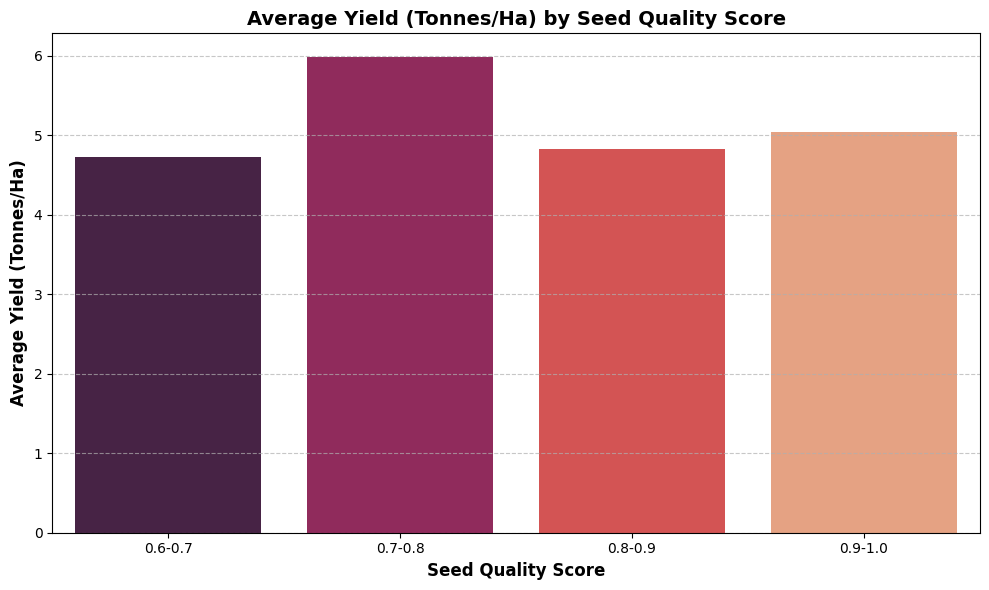

In [77]:
# Define bins for Seed_Quality_Score
bins = [0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
df['Seed_Quality_Category'] = pd.cut(df['Seed_Quality_Score'], bins=bins, labels=labels, right=False)

# Group by Seed_Quality_Category and calculate mean yield
seed_quality_yield = df.groupby('Seed_Quality_Category')['Yield_Tonnes_Ha'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Seed_Quality_Category', y='Yield_Tonnes_Ha', data=seed_quality_yield, palette='rocket')
plt.title('Average Yield (Tonnes/Ha) by Seed Quality Score', fontsize=14, fontweight='bold')
plt.xlabel('Seed Quality Score', fontsize=12, fontweight='bold')
plt.ylabel('Average Yield (Tonnes/Ha)', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

States vs Average Yield

State
Andhra Pradesh    4.630964
Gujarat           5.760886
Karnataka         5.751766
Madhya Pradesh    4.984851
Maharashtra       5.013453
Punjab            6.121116
Tamil Nadu        4.871460
Telangana         5.054321
Name: Yield_Tonnes_Ha, dtype: float64


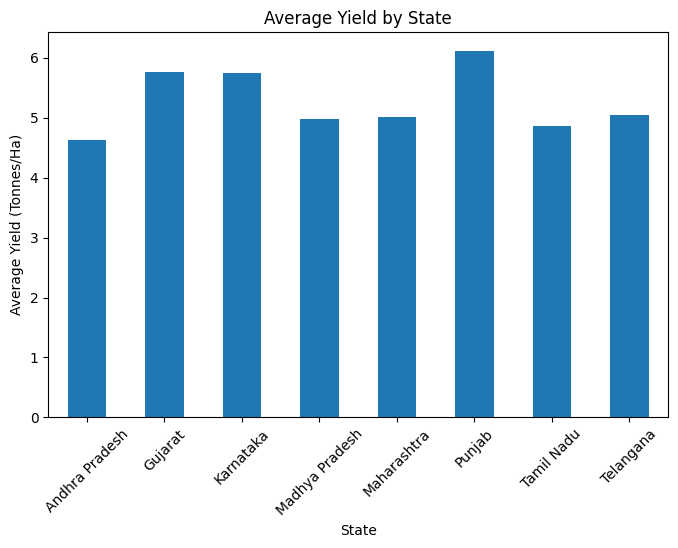

In [27]:
state_yield = df.groupby("State")["Yield_Tonnes_Ha"].mean()

print(state_yield)

state_yield.plot(kind="bar", figsize=(8, 5))

plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.title("Average Yield by State")
plt.xticks(rotation=45)

plt.show()

Average Yield Vs Season

Season
Kharif    5.628728
Rabi      5.092678
Zaid      4.633128
Name: Yield_Tonnes_Ha, dtype: float64


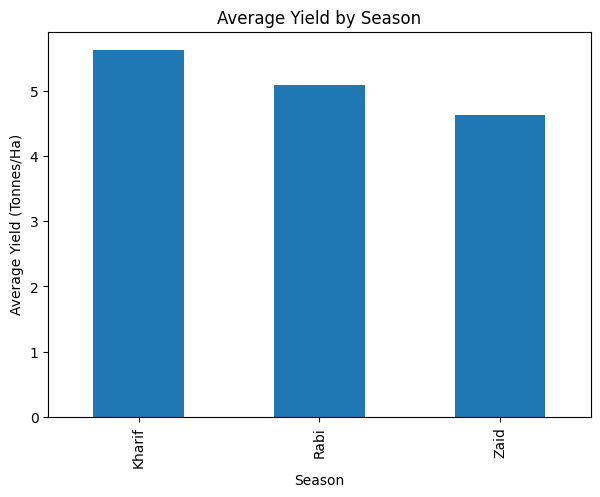

In [28]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

print(season_yield)

season_yield.plot(kind="bar", figsize=(7, 5))

plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.title("Average Yield by Season")

plt.show()

Season vs Proft/Loss percentage

Season
Kharif    35.450455
Rabi      17.597664
Zaid      -2.467071
Name: Profit_Loss_Pct, dtype: float64


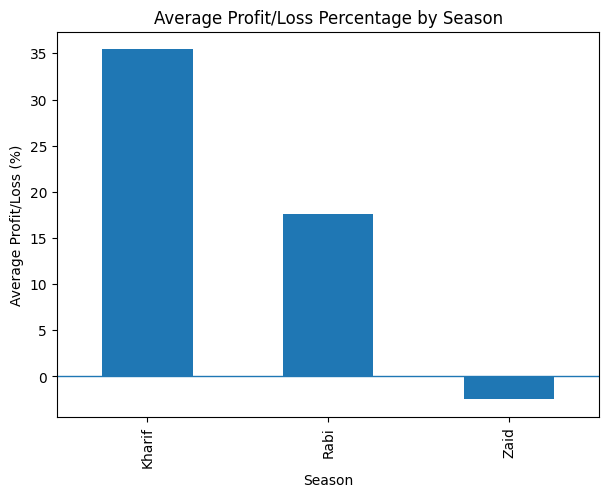

In [29]:
season_profit = df.groupby("Season")["Profit_Loss_Pct"].mean()

print(season_profit)

season_profit.plot(kind="bar", figsize=(7, 5))

plt.axhline(y=0, linewidth=1)

plt.xlabel("Season")
plt.ylabel("Average Profit/Loss (%)")
plt.title("Average Profit/Loss Percentage by Season")

plt.show()

Here We could understand that there is no proper yield at Higly acidic and basic Soil pH conditions

pH_Group
<5.5       0.610746
5.5-6.0    2.987433
6.0-6.5    6.470639
6.5-7.0    7.107614
7.0-7.5    5.201674
7.5-8.0    1.329566
>8.0       0.570230
Name: Yield_Tonnes_Ha, dtype: float64


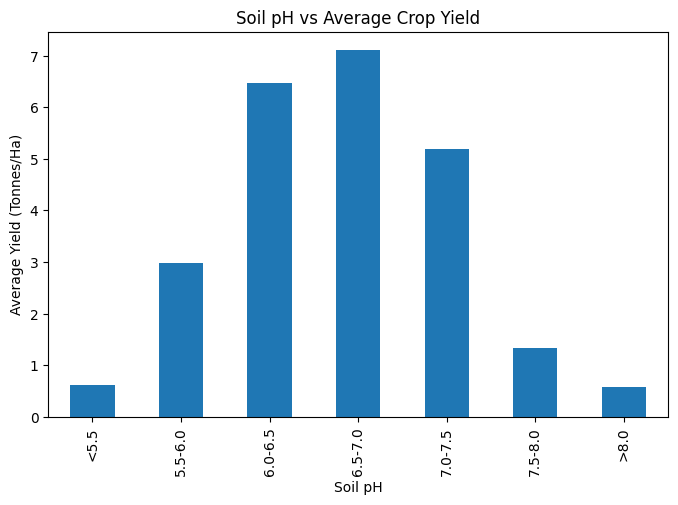

In [30]:
df["pH_Group"] = pd.cut(
    df["Soil_pH"],
    bins=[0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 14],
    labels=[
        "<5.5",
        "5.5-6.0",
        "6.0-6.5",
        "6.5-7.0",
        "7.0-7.5",
        "7.5-8.0",
        ">8.0"
    ]
)

ph_yield = df.groupby("pH_Group", observed=True)["Yield_Tonnes_Ha"].mean()

print(ph_yield)

ph_yield.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Soil pH")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.title("Soil pH vs Average Crop Yield")

plt.show()

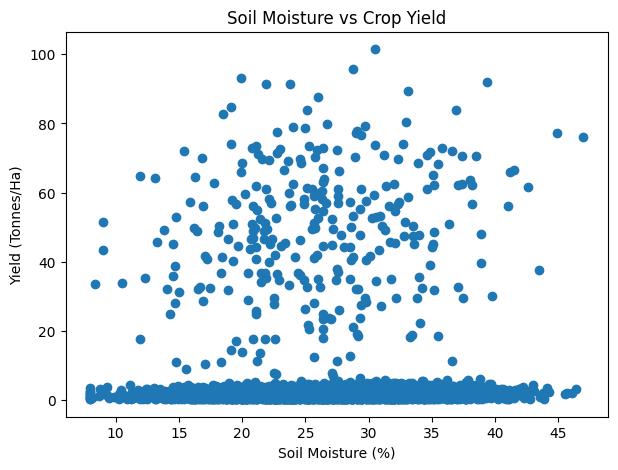

In [60]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Soil_Moisture_pct"],
    df["Yield_Tonnes_Ha"]
)

plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.title("Soil Moisture vs Crop Yield")

plt.show()

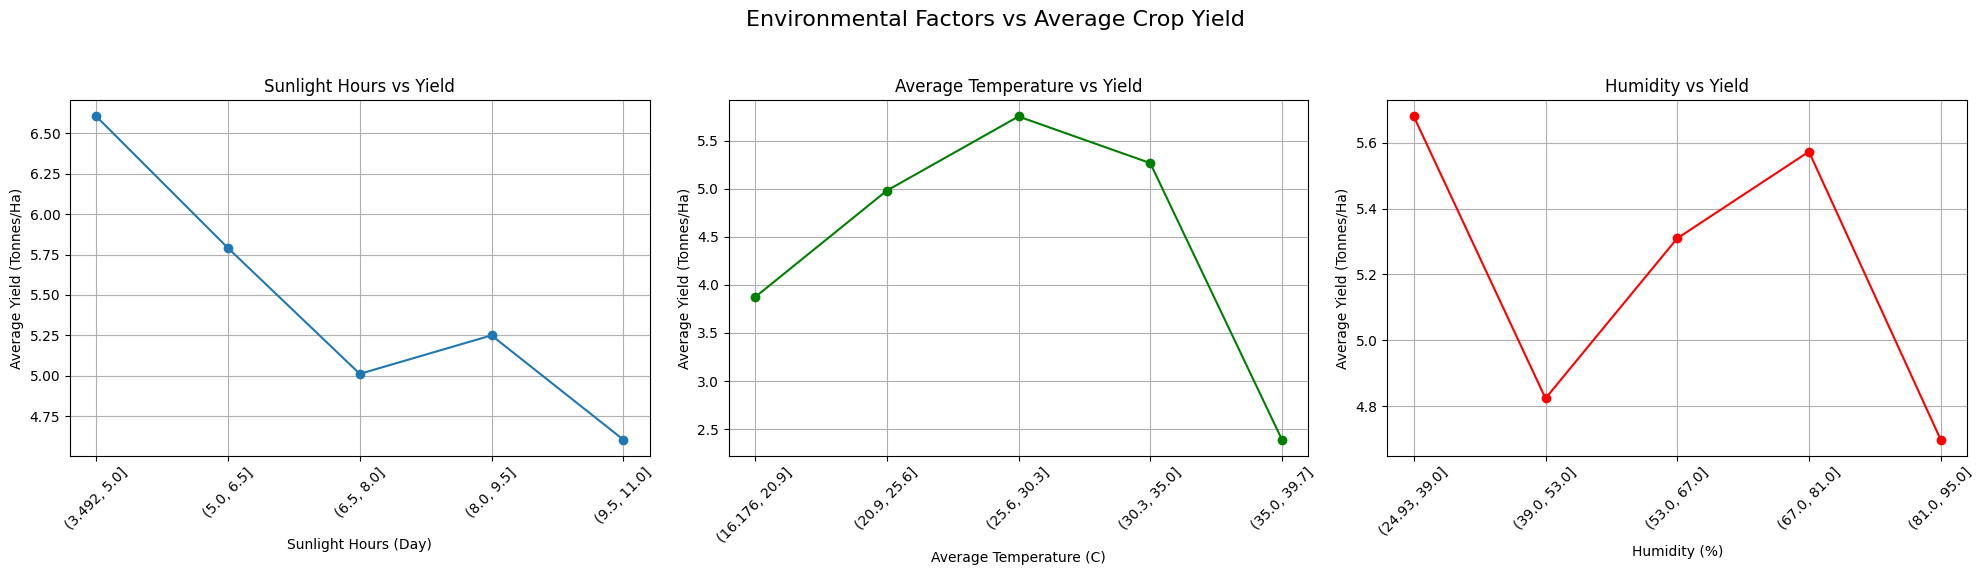

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Environmental Factors vs Average Crop Yield', fontsize=16)

# Sunlight_Hours_Day vs Yield
df['Sunlight_Group'] = pd.cut(df['Sunlight_Hours_Day'], bins=5)
sunlight_yield = df.groupby('Sunlight_Group', observed=True)['Yield_Tonnes_Ha'].mean().reset_index()
axes[0].plot(sunlight_yield['Sunlight_Group'].astype(str), sunlight_yield['Yield_Tonnes_Ha'], marker='o')
axes[0].set_title('Sunlight Hours vs Yield')
axes[0].set_xlabel('Sunlight Hours (Day)')
axes[0].set_ylabel('Average Yield (Tonnes/Ha)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

# Avg_Temperature_C vs Yield
df['Temperature_Group'] = pd.cut(df['Avg_Temperature_C'], bins=5)
temperature_yield = df.groupby('Temperature_Group', observed=True)['Yield_Tonnes_Ha'].mean().reset_index()
axes[1].plot(temperature_yield['Temperature_Group'].astype(str), temperature_yield['Yield_Tonnes_Ha'], marker='o', color='green')
axes[1].set_title('Average Temperature vs Yield')
axes[1].set_xlabel('Average Temperature (C)')
axes[1].set_ylabel('Average Yield (Tonnes/Ha)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)

# Humidity_pct vs Yield
df['Humidity_Group'] = pd.cut(df['Humidity_pct'], bins=5)
humidity_yield = df.groupby('Humidity_Group', observed=True)['Yield_Tonnes_Ha'].mean().reset_index()
axes[2].plot(humidity_yield['Humidity_Group'].astype(str), humidity_yield['Yield_Tonnes_Ha'], marker='o', color='red')
axes[2].set_title('Humidity vs Yield')
axes[2].set_xlabel('Humidity (%)')
axes[2].set_ylabel('Average Yield (Tonnes/Ha)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Here we could understand that the risk of Pest Disease decreases as the Pesticide Quantity Increases

Pesticide_Group
(0.488, 2.816]    55.942256
(2.816, 5.132]    49.238477
(5.132, 7.448]    43.180588
(7.448, 9.764]    37.410755
(9.764, 12.08]    27.730769
Name: Disease_Pest_Risk_pct, dtype: float64


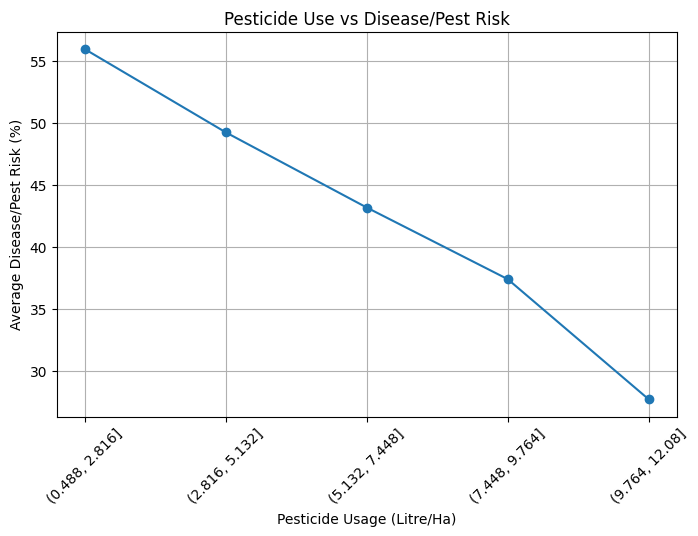

In [33]:
df["Pesticide_Group"] = pd.cut(
    df["Pesticide_Litre_ha"],
    bins=5
)

# Calculate average disease/pest risk for each group
pesticide_risk = df.groupby(
    "Pesticide_Group",
    observed=True
)["Disease_Pest_Risk_pct"].mean()

print(pesticide_risk)

# Line graph
plt.figure(figsize=(8, 5))

plt.plot(
    pesticide_risk.index.astype(str),
    pesticide_risk.values,
    marker="o"
)

plt.xlabel("Pesticide Usage (Litre/Ha)")
plt.ylabel("Average Disease/Pest Risk (%)")
plt.title("Pesticide Use vs Disease/Pest Risk")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

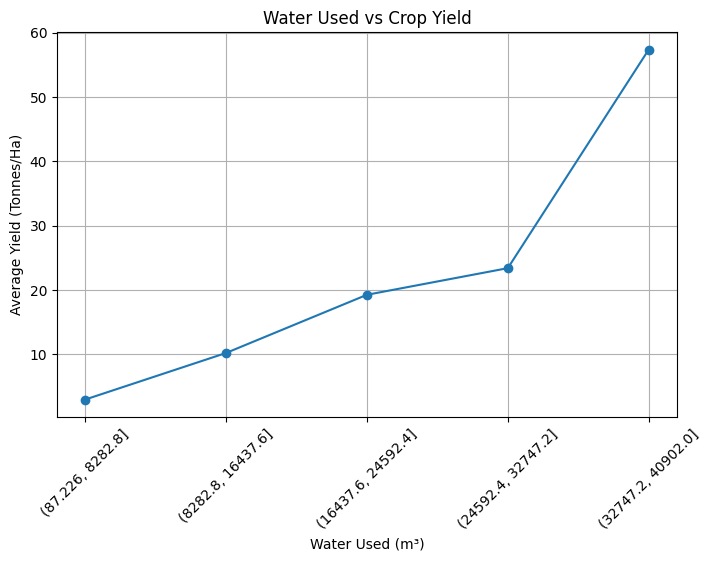

In [34]:
df["Water_Group"] = pd.cut(
    df["Water_Used_m3"],
    bins=5
)

water_yield = df.groupby(
    "Water_Group",
    observed=True
)["Yield_Tonnes_Ha"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    water_yield.index.astype(str),
    water_yield.values,
    marker="o"
)

plt.xlabel("Water Used (m³)")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.title("Water Used vs Crop Yield")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [45]:
df['expenses']=df['Total_Cost_INR']-df['Profit_INR']


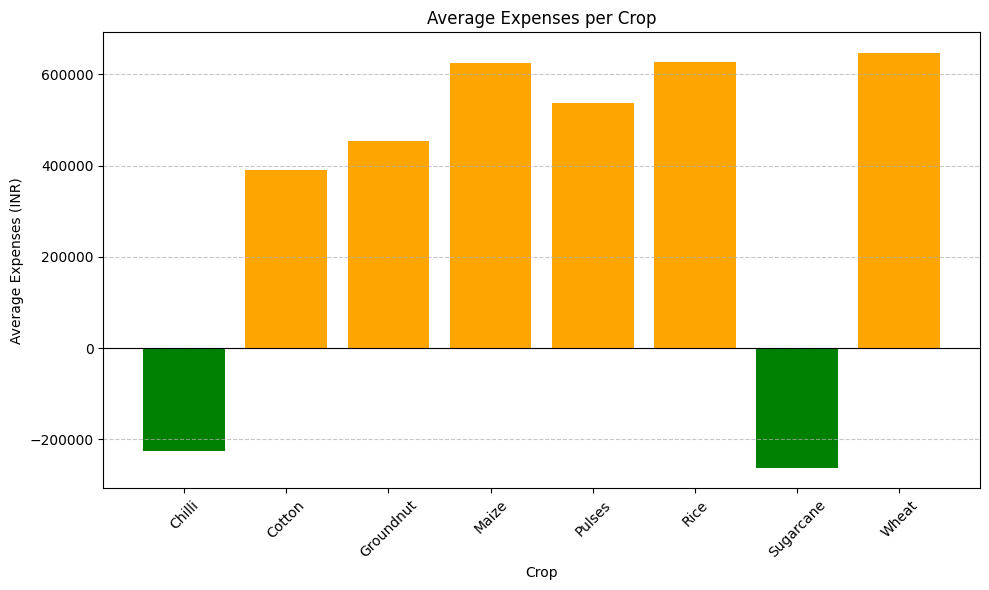

In [79]:
avg_expenses_by_crop = df.groupby('Crop')['expenses'].mean().reset_index()

plt.figure(figsize=(10, 6))
colors = ['green' if x < 0 else 'orange' for x in avg_expenses_by_crop['expenses']]
plt.bar(avg_expenses_by_crop['Crop'], avg_expenses_by_crop['expenses'], color=colors)
plt.xlabel('Crop')
plt.ylabel('Average Expenses (INR)')
plt.title('Average Expenses per Crop')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Irrigation_Method
Drip         6.267129
Flood        3.438853
Rainfed      7.563784
Sprinkler    4.669805
Name: Water_Efficiency_t_per_1000m3, dtype: float64


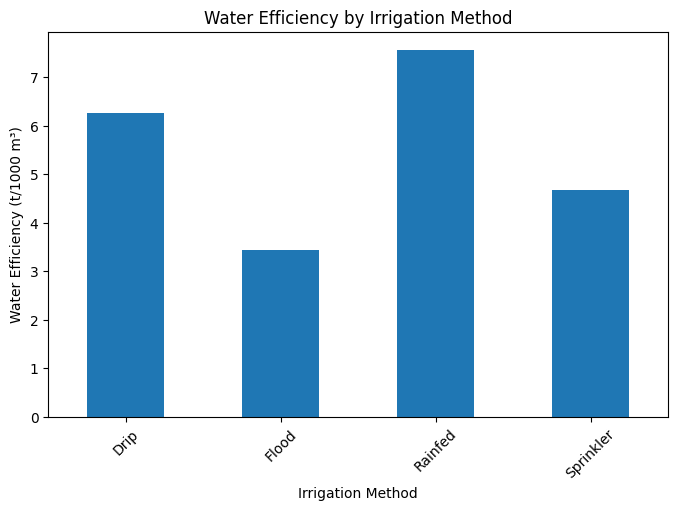

In [67]:
irrigation_water = df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean()

print(irrigation_water)

irrigation_water.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (t/1000 m³)")
plt.title("Water Efficiency by Irrigation Method")
plt.xticks(rotation=45)

plt.show()

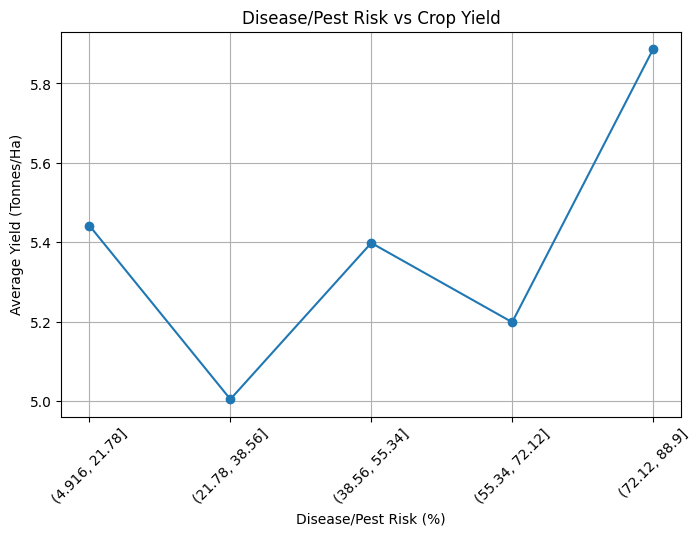

In [69]:
df["Disease_Risk_Group"] = pd.cut(
    df["Disease_Pest_Risk_pct"],
    bins=5
)

risk_yield = df.groupby(
    "Disease_Risk_Group",
    observed=True
)["Yield_Tonnes_Ha"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    risk_yield.index.astype(str),
    risk_yield.values,
    marker="o"
)

plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.title("Disease/Pest Risk vs Crop Yield")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()